# 🩺 Chronic Kidney Disease — ML Model Training & Evaluation
**Models:** Random Forest | SVM | Logistic Regression | XGBoost  
**Goal:** Train all models, compare full metrics per model, auto-select the best, and dump only that model.

## 📦 Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

print('✔ All libraries imported successfully')

✔ All libraries imported successfully


## 📂 Cell 2 — Load Data

In [2]:
df = pd.read_csv('../../datasets/kidney_disease_dataset.csv')

print('Shape:', df.shape)
print('\nColumn names:', df.columns.tolist())
print('\nFirst 5 rows:')
display(df.head())
print('\nData types:')
display(df.dtypes)

Shape: (20538, 43)

Column names: ['Age of the patient', 'Blood pressure (mm/Hg)', 'Specific gravity of urine', 'Albumin in urine', 'Sugar in urine', 'Red blood cells in urine', 'Pus cells in urine', 'Pus cell clumps in urine', 'Bacteria in urine', 'Random blood glucose level (mg/dl)', 'Blood urea (mg/dl)', 'Serum creatinine (mg/dl)', 'Sodium level (mEq/L)', 'Potassium level (mEq/L)', 'Hemoglobin level (gms)', 'Packed cell volume (%)', 'White blood cell count (cells/cumm)', 'Red blood cell count (millions/cumm)', 'Hypertension (yes/no)', 'Diabetes mellitus (yes/no)', 'Coronary artery disease (yes/no)', 'Appetite (good/poor)', 'Pedal edema (yes/no)', 'Anemia (yes/no)', 'Estimated Glomerular Filtration Rate (eGFR)', 'Urine protein-to-creatinine ratio', 'Urine output (ml/day)', 'Serum albumin level', 'Cholesterol level', 'Parathyroid hormone (PTH) level', 'Serum calcium level', 'Serum phosphate level', 'Family history of chronic kidney disease', 'Smoking status', 'Body Mass Index (BMI)', 

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Smoking status,Body Mass Index (BMI),Physical activity level,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target
0,54,167,1.023,1,4,normal,abnormal,not present,not present,96,...,yes,25.3,low,4,16,0.67,normal,4.88,10.23,No_Disease
1,42,127,1.023,3,2,normal,normal,not present,present,73,...,no,20.6,moderate,3,13,0.55,abnormal,4.49,13.11,Low_Risk
2,38,148,1.016,0,0,abnormal,normal,not present,not present,77,...,no,38.4,high,11,23,2.37,abnormal,4.57,13.27,No_Disease
3,7,98,1.017,4,0,abnormal,normal,not present,present,225,...,no,24.7,high,24,3,2.54,abnormal,8.57,12.36,No_Disease
4,67,174,1.015,1,1,normal,abnormal,not present,not present,376,...,yes,17.6,high,22,24,1.90,normal,6.75,1.46,No_Disease



Data types:


Age of the patient                               int64
Blood pressure (mm/Hg)                           int64
Specific gravity of urine                      float64
Albumin in urine                                 int64
Sugar in urine                                   int64
Red blood cells in urine                           str
Pus cells in urine                                 str
Pus cell clumps in urine                           str
Bacteria in urine                                  str
Random blood glucose level (mg/dl)               int64
Blood urea (mg/dl)                             float64
Serum creatinine (mg/dl)                       float64
Sodium level (mEq/L)                           float64
Potassium level (mEq/L)                        float64
Hemoglobin level (gms)                         float64
Packed cell volume (%)                           int64
White blood cell count (cells/cumm)              int64
Red blood cell count (millions/cumm)           float64
Hypertensi

## 🔍 Cell 3 — Missing Value Analysis

In [3]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('Columns with missing values:')

if missing_df.empty:
    print('  ✔ No missing values found — cleaning may have already run, or data is complete.')
    print('\n  Current df shape:', df.shape)
    print('  NaN total:', df.isnull().sum().sum())
else:
    display(missing_df)

    plt.figure(figsize=(10, 4))
    missing_df['Missing %'].plot(kind='bar', color='salmon', edgecolor='white')
    plt.title('Missing Value % per Column')
    plt.ylabel('Missing %')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

Columns with missing values:
  ✔ No missing values found — cleaning may have already run, or data is complete.

  Current df shape: (20538, 43)
  NaN total: 0


## 🧹 Cell 4 — Data Cleaning

In [4]:
# Drop ID
df.drop(columns=['id'], errors='ignore', inplace=True)

# Strip whitespace
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

# Replace literal artifacts with NaN (no regex needed)
df.replace(to_replace=['?', '\t'], value=np.nan, inplace=True)

# Also catch tab-prefixed values using regex separately
df.replace(to_replace=r'^\t', value=np.nan, regex=True, inplace=True)

# Coerce numeric columns
numeric_cols = ['age','bp','sg','al','su','bgr','bu','sc','sod','pot','hemo','pcv','wc','rc']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print('✔ Cleaning done')
print('Shape after cleaning:', df.shape)
display(df.head())

✔ Cleaning done
Shape after cleaning: (20538, 43)


,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Smoking status,Body Mass Index (BMI),Physical activity level,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target
0,54,167,1.023,1,4,normal,abnormal,not present,not present,96,...,yes,25.3,low,4,16,0.67,normal,4.88,10.23,No_Disease
1,42,127,1.023,3,2,normal,normal,not present,present,73,...,no,20.6,moderate,3,13,0.55,abnormal,4.49,13.11,Low_Risk
2,38,148,1.016,0,0,abnormal,normal,not present,not present,77,...,no,38.4,high,11,23,2.37,abnormal,4.57,13.27,No_Disease
3,7,98,1.017,4,0,abnormal,normal,not present,present,225,...,no,24.7,high,24,3,2.54,abnormal,8.57,12.36,No_Disease
4,67,174,1.015,1,1,normal,abnormal,not present,not present,376,...,yes,17.6,high,22,24,1.90,normal,6.75,1.46,No_Disease


## 🎯 Cell 5 — Target Encoding & Class Distribution

In [5]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('Columns with missing values:')
display(missing_df)

# Only plot if there are missing values
if not missing_df.empty:
    plt.figure(figsize=(10, 4))
    missing_df['Missing %'].plot(kind='bar', color='salmon', edgecolor='white')
    plt.title('Missing Value % per Column')
    plt.ylabel('Missing %')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found.')

Columns with missing values:


,Missing Count,Missing %


No missing values found.


In [6]:
# Clean all column names at once (strip whitespace, lowercase)
df.columns = df.columns.str.strip().str.lower()

# Verify
print(df.columns.tolist())

['age of the patient', 'blood pressure (mm/hg)', 'specific gravity of urine', 'albumin in urine', 'sugar in urine', 'red blood cells in urine', 'pus cells in urine', 'pus cell clumps in urine', 'bacteria in urine', 'random blood glucose level (mg/dl)', 'blood urea (mg/dl)', 'serum creatinine (mg/dl)', 'sodium level (meq/l)', 'potassium level (meq/l)', 'hemoglobin level (gms)', 'packed cell volume (%)', 'white blood cell count (cells/cumm)', 'red blood cell count (millions/cumm)', 'hypertension (yes/no)', 'diabetes mellitus (yes/no)', 'coronary artery disease (yes/no)', 'appetite (good/poor)', 'pedal edema (yes/no)', 'anemia (yes/no)', 'estimated glomerular filtration rate (egfr)', 'urine protein-to-creatinine ratio', 'urine output (ml/day)', 'serum albumin level', 'cholesterol level', 'parathyroid hormone (pth) level', 'serum calcium level', 'serum phosphate level', 'family history of chronic kidney disease', 'smoking status', 'body mass index (bmi)', 'physical activity level', 'durati

## ⚙️ Cell 6 — Preprocessing (Impute + Encode + Scale + Split)

In [7]:
target_col = 'target'  # was 'classification' — your CSV uses 'target'

X = df.drop(columns=[target_col])
y = df[target_col]

cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Imputation
num_imputer = SimpleImputer(strategy='median')
X[num_cols] = num_imputer.fit_transform(X[num_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

# Label encode
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling (for LR and SVM)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

SCALED_MODELS = {'Logistic Regression', 'SVM'}

print(f'✔ Feature matrix : {X.shape}')
print(f'   Train size     : {X_train.shape[0]} samples')
print(f'   Test size      : {X_test.shape[0]} samples')

✔ Feature matrix : (20538, 42)
   Train size     : 16430 samples
   Test size      : 4108 samples


In [8]:
print(y.unique())
print(y.value_counts())

<StringArray>
['No_Disease', 'Low_Risk', 'Moderate_Risk', 'Severe_Disease', 'High_Risk']
Length: 5, dtype: str
target
No_Disease        16432
Low_Risk           2054
Moderate_Risk       821
High_Risk           821
Severe_Disease      410
Name: count, dtype: int64


## 🌲 Cell 7 — Train & Evaluate: Random Forest

In [9]:
# Encode the target properly
from sklearn.preprocessing import LabelEncoder
le_target = LabelEncoder()
y = le_target.fit_transform(y)  # 'ckd'->1, 'notckd'->0 (alphabetical)

print('Classes:', le_target.classes_)  # verify which is 0 and which is 1

# Re-do the split after encoding
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Classes: ['High_Risk' 'Low_Risk' 'Moderate_Risk' 'No_Disease' 'Severe_Disease']


In [10]:
summary = {}
trained  = {}

def evaluate_model(name, model, Xtr, Xte, y_train, y_test):
    model.fit(Xtr, y_train)
    y_pred  = model.predict(Xte)

    n_classes = len(np.unique(y_test))
    is_binary = n_classes == 2

    # For ROC-AUC: binary needs [:, 1], multiclass needs all probas
    y_proba = model.predict_proba(Xte)
    if is_binary:
        roc_auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

    metrics = {
        'Accuracy':          accuracy_score(y_test, y_pred),
        'Precision (macro)': precision_score(y_test, y_pred, average='macro',    zero_division=0),
        'Recall (macro)':    recall_score(y_test, y_pred,    average='macro',    zero_division=0),
        'F1 (macro)':        f1_score(y_test, y_pred,        average='macro',    zero_division=0),
        'Precision (CKD)':   precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall (CKD)':      recall_score(y_test, y_pred,    average='weighted', zero_division=0),
        'F1 (CKD)':          f1_score(y_test, y_pred,        average='weighted', zero_division=0),
        'ROC-AUC':           roc_auc,
        'CV-5 Accuracy':     cross_val_score(model, Xtr, y_train, cv=5, scoring='accuracy').mean(),
        '_y_pred':  y_pred,
        '_y_proba': y_proba,
        '_cm':      confusion_matrix(y_test, y_pred),
    }
    return model, metrics

# ── RANDOM FOREST ──────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, random_state=42)
trained['Random Forest'], summary['Random Forest'] = evaluate_model(
    'Random Forest', rf, X_train.values, X_test.values, y_train, y_test
)
m = summary['Random Forest']
print('=' * 55)
print('  MODEL : Random Forest')
print('=' * 55)
print(f"  Accuracy        : {m['Accuracy']:.4f}")
print(f"  ROC-AUC         : {m['ROC-AUC']:.4f}")
print(f"  CV-5 Accuracy   : {m['CV-5 Accuracy']:.4f}")
print(f"\n  Weighted avg →  Precision: {m['Precision (CKD)']:.4f}  Recall: {m['Recall (CKD)']:.4f}  F1: {m['F1 (CKD)']:.4f}")
print(f"  Macro avg    →  Precision: {m['Precision (macro)']:.4f}  Recall: {m['Recall (macro)']:.4f}  F1: {m['F1 (macro)']:.4f}")
print('\nFull Classification Report:')
print(classification_report(y_test, m['_y_pred'], digits=4))
print('Confusion Matrix:')
display(pd.DataFrame(
    m['_cm'],
    index=[f'Actual: {c}' for c in np.unique(y_test)],
    columns=[f'Pred: {c}' for c in np.unique(y_test)]
))

  MODEL : Random Forest
  Accuracy        : 0.8001
  ROC-AUC         : 0.5060
  CV-5 Accuracy   : 0.8001

  Weighted avg →  Precision: 0.6402  Recall: 0.8001  F1: 0.7113
  Macro avg    →  Precision: 0.1600  Recall: 0.2000  F1: 0.1778

Full Classification Report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       164
           1     0.0000    0.0000    0.0000       411
           2     0.0000    0.0000    0.0000       164
           3     0.8001    1.0000    0.8890      3287
           4     0.0000    0.0000    0.0000        82

    accuracy                         0.8001      4108
   macro avg     0.1600    0.2000    0.1778      4108
weighted avg     0.6402    0.8001    0.7113      4108

Confusion Matrix:


,Pred: 0,Pred: 1,Pred: 2,Pred: 3,Pred: 4
Actual: 0,0,0,0,164,0
Actual: 1,0,0,0,411,0
Actual: 2,0,0,0,164,0
Actual: 3,0,0,0,3287,0
Actual: 4,0,0,0,82,0


## 🔵 Cell 8 — Train & Evaluate: SVM

In [11]:
svm = SVC(probability=True, kernel='rbf', C=1.0, random_state=42)
trained['SVM'], summary['SVM'] = evaluate_model(
    'SVM', svm, X_train_sc, X_test_sc, y_train, y_test
)
m = summary['SVM']
print('=' * 55)
print('  MODEL : SVM')
print('=' * 55)
print(f"  Accuracy        : {m['Accuracy']:.4f}")
print(f"  ROC-AUC         : {m['ROC-AUC']:.4f}")
print(f"  CV-5 Accuracy   : {m['CV-5 Accuracy']:.4f}")
print(f"\n  Weighted avg →  Precision: {m['Precision (CKD)']:.4f}  Recall: {m['Recall (CKD)']:.4f}  F1: {m['F1 (CKD)']:.4f}")
print(f"  Macro avg    →  Precision: {m['Precision (macro)']:.4f}  Recall: {m['Recall (macro)']:.4f}  F1: {m['F1 (macro)']:.4f}")
print('\nFull Classification Report:')
print(classification_report(y_test, m['_y_pred'], digits=4))
print('Confusion Matrix:')
display(pd.DataFrame(
    m['_cm'],
    index=[f'Actual: {c}' for c in np.unique(y_test)],
    columns=[f'Pred: {c}' for c in np.unique(y_test)]
))

  MODEL : SVM
  Accuracy        : 0.8001
  ROC-AUC         : 0.4953
  CV-5 Accuracy   : 0.8001

  Weighted avg →  Precision: 0.6402  Recall: 0.8001  F1: 0.7113
  Macro avg    →  Precision: 0.1600  Recall: 0.2000  F1: 0.1778

Full Classification Report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       164
           1     0.0000    0.0000    0.0000       411
           2     0.0000    0.0000    0.0000       164
           3     0.8001    1.0000    0.8890      3287
           4     0.0000    0.0000    0.0000        82

    accuracy                         0.8001      4108
   macro avg     0.1600    0.2000    0.1778      4108
weighted avg     0.6402    0.8001    0.7113      4108

Confusion Matrix:


,Pred: 0,Pred: 1,Pred: 2,Pred: 3,Pred: 4
Actual: 0,0,0,0,164,0
Actual: 1,0,0,0,411,0
Actual: 2,0,0,0,164,0
Actual: 3,0,0,0,3287,0
Actual: 4,0,0,0,82,0


## 🟠 Cell 9 — Train & Evaluate: Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
trained['Logistic Regression'], summary['Logistic Regression'] = evaluate_model(
    'Logistic Regression', lr,
    X_train_sc, X_test_sc,   # use scaled data for LR
    y_train, y_test
)

In [13]:
m = summary['Logistic Regression']
print('=' * 55)
print('  MODEL : Logistic Regression')
print('=' * 55)
print(f"  Accuracy        : {m['Accuracy']:.4f}")
print(f"  ROC-AUC         : {m['ROC-AUC']:.4f}")
print(f"  CV-5 Accuracy   : {m['CV-5 Accuracy']:.4f}")
print(f"\n  Weighted avg →  Precision: {m['Precision (CKD)']:.4f}  Recall: {m['Recall (CKD)']:.4f}  F1: {m['F1 (CKD)']:.4f}")
print(f"  Macro avg    →  Precision: {m['Precision (macro)']:.4f}  Recall: {m['Recall (macro)']:.4f}  F1: {m['F1 (macro)']:.4f}")
print('\nFull Classification Report:')
print(classification_report(y_test, m['_y_pred'], digits=4))
print('Confusion Matrix:')
display(pd.DataFrame(
    m['_cm'],
    index=[f'Actual: {c}' for c in np.unique(y_test)],
    columns=[f'Pred: {c}' for c in np.unique(y_test)]
))

  MODEL : Logistic Regression
  Accuracy        : 0.8001
  ROC-AUC         : 0.4941
  CV-5 Accuracy   : 0.8001

  Weighted avg →  Precision: 0.6402  Recall: 0.8001  F1: 0.7113
  Macro avg    →  Precision: 0.1600  Recall: 0.2000  F1: 0.1778

Full Classification Report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       164
           1     0.0000    0.0000    0.0000       411
           2     0.0000    0.0000    0.0000       164
           3     0.8001    1.0000    0.8890      3287
           4     0.0000    0.0000    0.0000        82

    accuracy                         0.8001      4108
   macro avg     0.1600    0.2000    0.1778      4108
weighted avg     0.6402    0.8001    0.7113      4108

Confusion Matrix:


,Pred: 0,Pred: 1,Pred: 2,Pred: 3,Pred: 4
Actual: 0,0,0,0,164,0
Actual: 1,0,0,0,411,0
Actual: 2,0,0,0,164,0
Actual: 3,0,0,0,3287,0
Actual: 4,0,0,0,82,0


## 🟣 Cell 10 — Train & Evaluate: XGBoost

In [14]:
xgb = XGBClassifier(n_estimators=200, learning_rate=0.1,
                    eval_metric='logloss', random_state=42)  # removed deprecated use_label_encoder
trained['XGBoost'], summary['XGBoost'] = evaluate_model(
    'XGBoost', xgb, X_train.values, X_test.values, y_train, y_test
)
m = summary['XGBoost']
print('=' * 55)
print('  MODEL : XGBoost')
print('=' * 55)
print(f"  Accuracy        : {m['Accuracy']:.4f}")
print(f"  ROC-AUC         : {m['ROC-AUC']:.4f}")
print(f"  CV-5 Accuracy   : {m['CV-5 Accuracy']:.4f}")
print(f"\n  Weighted avg →  Precision: {m['Precision (CKD)']:.4f}  Recall: {m['Recall (CKD)']:.4f}  F1: {m['F1 (CKD)']:.4f}")
print(f"  Macro avg    →  Precision: {m['Precision (macro)']:.4f}  Recall: {m['Recall (macro)']:.4f}  F1: {m['F1 (macro)']:.4f}")
print('\nFull Classification Report:')
print(classification_report(y_test, m['_y_pred'], digits=4))
print('Confusion Matrix:')
display(pd.DataFrame(m['_cm'],
    index=[f'Actual: {c}' for c in np.unique(y_test)],
    columns=[f'Pred: {c}' for c in np.unique(y_test)]))

  MODEL : XGBoost
  Accuracy        : 0.7999
  ROC-AUC         : 0.5035
  CV-5 Accuracy   : 0.8000

  Weighted avg →  Precision: 0.6402  Recall: 0.7999  F1: 0.7112
  Macro avg    →  Precision: 0.1600  Recall: 0.1999  F1: 0.1778

Full Classification Report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       164
           1     0.0000    0.0000    0.0000       411
           2     0.0000    0.0000    0.0000       164
           3     0.8001    0.9997    0.8888      3287
           4     0.0000    0.0000    0.0000        82

    accuracy                         0.7999      4108
   macro avg     0.1600    0.1999    0.1778      4108
weighted avg     0.6402    0.7999    0.7112      4108

Confusion Matrix:


,Pred: 0,Pred: 1,Pred: 2,Pred: 3,Pred: 4
Actual: 0,0,0,0,164,0
Actual: 1,0,0,0,411,0
Actual: 2,0,0,0,164,0
Actual: 3,0,1,0,3286,0
Actual: 4,0,0,0,82,0


## 📊 Cell 11 — Model Comparison Table

In [15]:
display_keys = ['Accuracy','Precision (macro)','Recall (macro)',
                'F1 (macro)','ROC-AUC','CV-5 Accuracy']

comp_df = pd.DataFrame(
    {name: {k: summary[name][k] for k in display_keys} for name in summary}
).T.sort_values('ROC-AUC', ascending=False)

print('Model Comparison Summary (sorted by ROC-AUC):')
display(comp_df.style
        .format('{:.4f}')
        .highlight_max(axis=0, color='#c8e6c9')
        .set_caption('Green = best value per column'))

Model Comparison Summary (sorted by ROC-AUC):


,Accuracy,Precision (macro),Recall (macro),F1 (macro),ROC-AUC,CV-5 Accuracy
Random Forest,0.8001,0.1600,0.2000,0.1778,0.5060,0.8001
XGBoost,0.7999,0.1600,0.1999,0.1778,0.5035,0.8000
SVM,0.8001,0.1600,0.2000,0.1778,0.4953,0.8001
Logistic Regression,0.8001,0.1600,0.2000,0.1778,0.4941,0.8001


## 🏆 Cell 12 — Best Model Selection

In [16]:
best_name    = comp_df['ROC-AUC'].idxmax()
best_model   = trained[best_name]
y_pred_best  = summary[best_name]['_y_pred']
y_proba_best = summary[best_name]['_y_proba']

print('=' * 55)
print(f'  ✔  Best Model Selected : {best_name}')
print(f"  ✔  ROC-AUC             : {comp_df.loc[best_name, 'ROC-AUC']:.4f}")
print(f"  ✔  Accuracy            : {comp_df.loc[best_name, 'Accuracy']:.4f}")
print(f"  ✔  F1 (macro)          : {comp_df.loc[best_name, 'F1 (macro)']:.4f}")
print('=' * 55)

  ✔  Best Model Selected : Random Forest
  ✔  ROC-AUC             : 0.5060
  ✔  Accuracy            : 0.8001
  ✔  F1 (macro)          : 0.1778


## 🖼️ Cell 13 — Confusion Matrices (All Models)

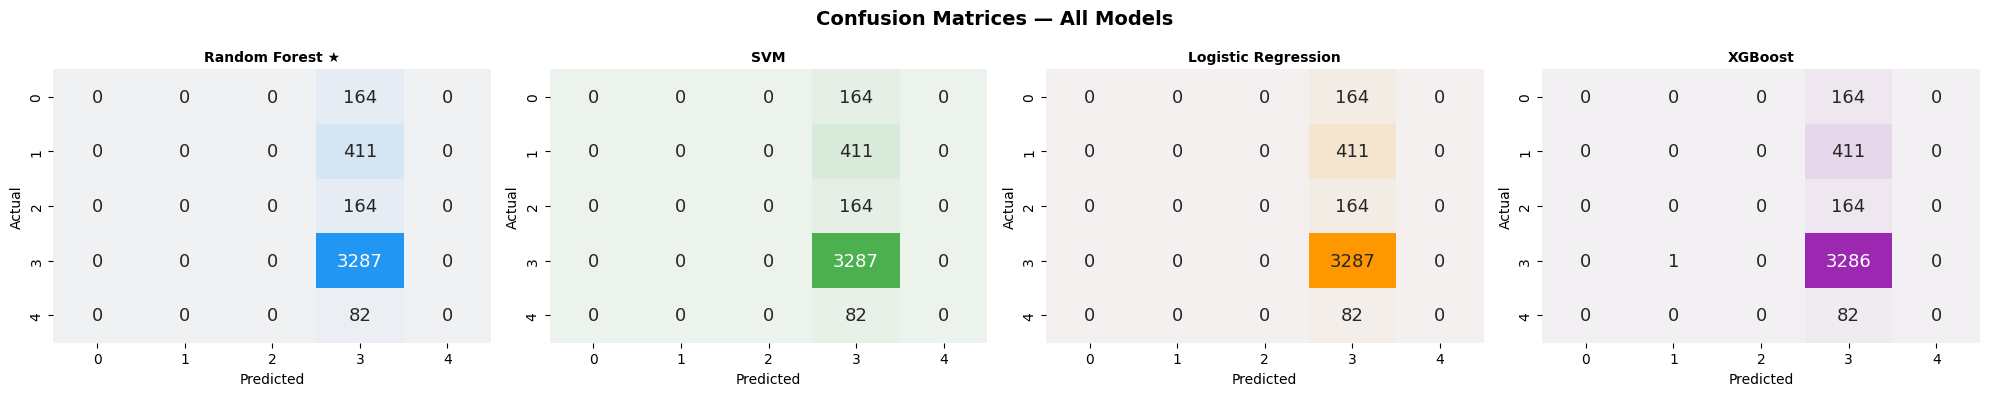

In [17]:
palette = {
    'Random Forest':      '#2196F3',
    'XGBoost':            '#9C27B0',
    'Logistic Regression':'#FF9800',
    'SVM':                '#4CAF50'
}
n_classes = len(np.unique(y_test))
class_labels = [str(c) for c in np.unique(y_test)]

fig, axes = plt.subplots(1, len(summary), figsize=(5 * len(summary), 4))
if len(summary) == 1:
    axes = [axes]
fig.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')

for ax, (name, info) in zip(axes, summary.items()):
    sns.heatmap(info['_cm'], annot=True, fmt='d',
                cmap=sns.light_palette(palette[name], as_cmap=True),
                xticklabels=class_labels,
                yticklabels=class_labels,
                ax=ax, cbar=False, annot_kws={'size': 13})
    star = ' ★' if name == best_name else ''
    ax.set_title(f'{name}{star}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## 📈 Cell 14 — ROC Curves (All Models)

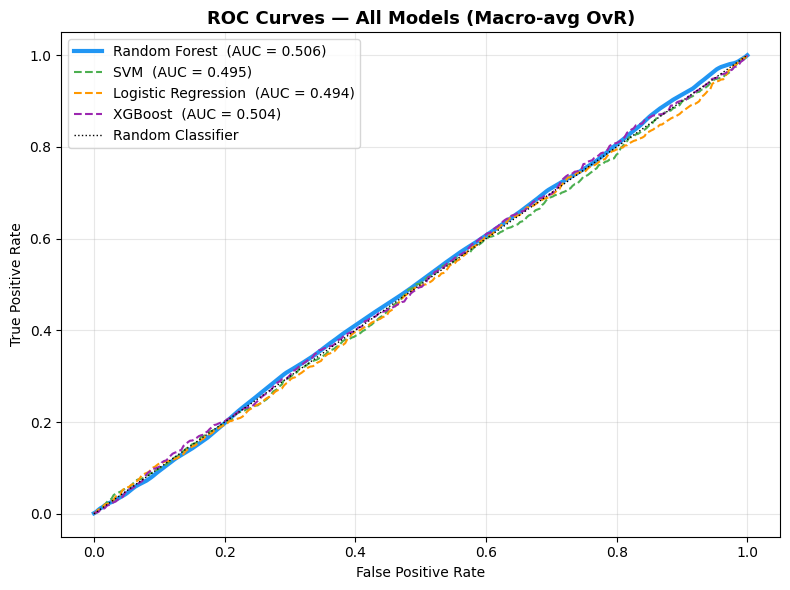

In [18]:
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import label_binarize

classes = np.unique(y_test)
n_classes = len(classes)

plt.figure(figsize=(8, 6))

for name, info in summary.items():
    y_proba = info['_y_proba']          # shape (n_samples, n_classes)
    y_bin   = label_binarize(y_test, classes=classes)  # shape (n_samples, n_classes)

    # Macro-average ROC: average FPR/TPR across all classes
    all_fpr = np.linspace(0, 1, 300)
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        mean_tpr += np.interp(all_fpr, fpr_i, tpr_i)

    mean_tpr /= n_classes

    lw = 3 if name == best_name else 1.5
    ls = '-' if name == best_name else '--'
    plt.plot(all_fpr, mean_tpr, color=palette[name], lw=lw, ls=ls,
             label=f"{name}  (AUC = {info['ROC-AUC']:.3f})")

plt.plot([0, 1], [0, 1], 'k:', lw=1, label='Random Classifier')
plt.title('ROC Curves — All Models (Macro-avg OvR)', fontsize=13, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 📉 Cell 15 — Metric Bar Chart (All Models)

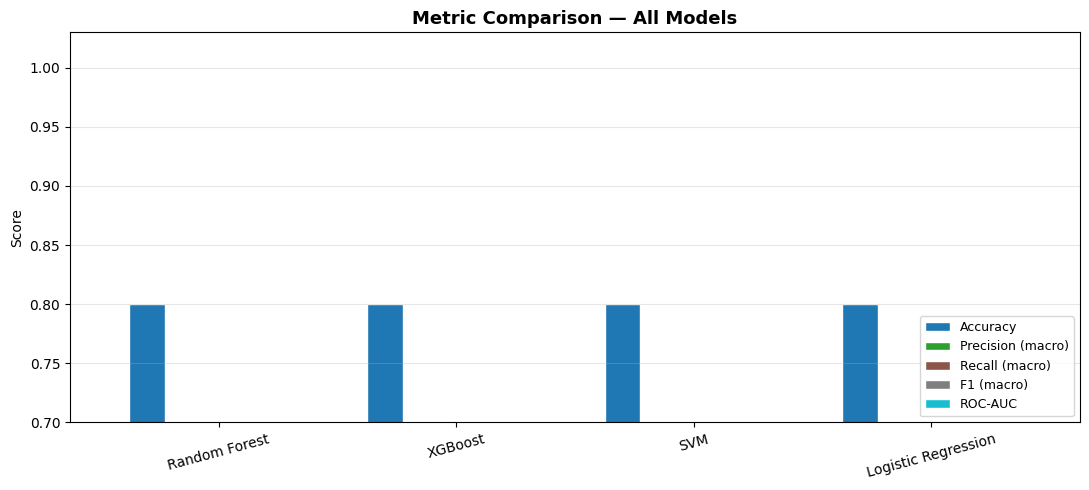

In [19]:
metrics_plot = ['Accuracy','Precision (macro)','Recall (macro)','F1 (macro)','ROC-AUC']

ax = comp_df[metrics_plot].plot(kind='bar', figsize=(11, 5),
                                 colormap='tab10', edgecolor='white', width=0.75)
plt.title('Metric Comparison — All Models', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0.70, 1.03)
plt.legend(fontsize=9, loc='lower right')
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 🌟 Cell 16 — Feature Importances (Best Model)

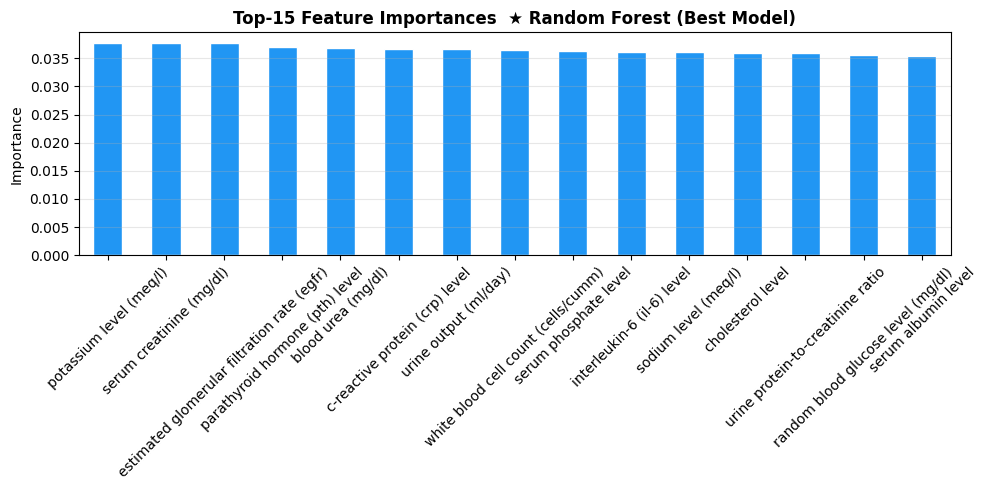

Top 15 feature importances:


,Feature,Importance
0,potassium level (meq/l),0.037730
1,serum creatinine (mg/dl),0.037706
2,estimated glomerular filtration rate (egfr),0.037646
3,parathyroid hormone (pth) level,0.037046
4,blood urea (mg/dl),0.036916
5,c-reactive protein (crp) level,0.036705
6,urine output (ml/day),0.036567
7,white blood cell count (cells/cumm),0.036499
8,serum phosphate level,0.036215
9,interleukin-6 (il-6) level,0.036207


In [20]:
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=X.columns)
    fi_top = fi.sort_values(ascending=False).head(15)

    plt.figure(figsize=(10, 5))
    fi_top.plot(kind='bar', color=palette[best_name], edgecolor='white')
    plt.title(f'Top-15 Feature Importances  ★ {best_name} (Best Model)',
              fontsize=12, fontweight='bold')
    plt.ylabel('Importance')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('Top 15 feature importances:')
    display(fi_top.reset_index().rename(columns={'index':'Feature', 0:'Importance'}))
else:
    print(f'Feature importances not available for {best_name}')

## 💾 Cell 17 — Save Best Model Only

In [21]:
import os

models_dir = '../../models'
os.makedirs(models_dir, exist_ok=True)

safe_name = best_name.replace(' ', '_')

joblib.dump(
    best_model,
    f'{models_dir}/best_model_{safe_name}.pkl',
    compress=3
)
joblib.dump(num_imputer, f'{models_dir}/preprocessor_num_imputer.pkl')
joblib.dump(cat_imputer, f'{models_dir}/preprocessor_cat_imputer.pkl')
joblib.dump(le_target,   f'{models_dir}/preprocessor_label_encoder.pkl')
# Add this to your saving cell in the notebook
joblib.dump(num_cols, f'{models_dir}/num_cols.pkl')
joblib.dump(cat_cols, f'{models_dir}/cat_cols.pkl')

print('   → num_cols.pkl')
print('   → cat_cols.pkl')

print('✔ Saved to:', os.path.abspath(models_dir))
print(f'   → best_model_{safe_name}.pkl')
print('   → preprocessor_num_imputer.pkl')
print('   → preprocessor_cat_imputer.pkl')
print('   → preprocessor_label_encoder.pkl')

   → num_cols.pkl
   → cat_cols.pkl
✔ Saved to: c:\Users\Admin\OneDrive\Desktop\Health-App\models
   → best_model_Random_Forest.pkl
   → preprocessor_num_imputer.pkl
   → preprocessor_cat_imputer.pkl
   → preprocessor_label_encoder.pkl
